### well structured - an ode to databases


# data unterstanding

### import libaries

In [1]:
import sqlite3
import pandas as pd
import numpy as np

### select all from table

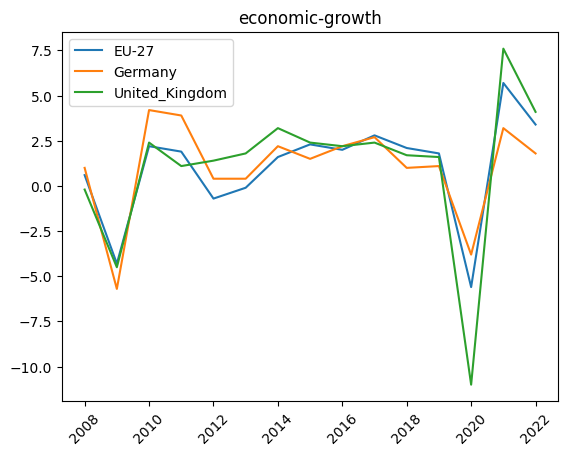

In [2]:
conn = sqlite3.connect('brexit.db')
#c = conn.cursor()

sql = "SELECT * FROM 'economic-growth'"
result = pd.read_sql(sql,conn)

year = result['Jahr'].tolist()
EU_27 = result['EU-27'].tolist()
Germany = result['Germany'].tolist()
United_Kingdom = result['United Kingdom'].tolist()

df = pd.DataFrame({'EU-27':EU_27, 'Germany': Germany, 'United_Kingdom':United_Kingdom}, index=year)
plot = df.plot(title="economic-growth", rot=45)

<font color='#5891db'> All curves are largely synchronous. They all have low points in 2008 and 2020. Peaks in economic growth are for the EU-27 and the United Kingdom in 2021 and for Germany in 2010.</font>

### select one column from table

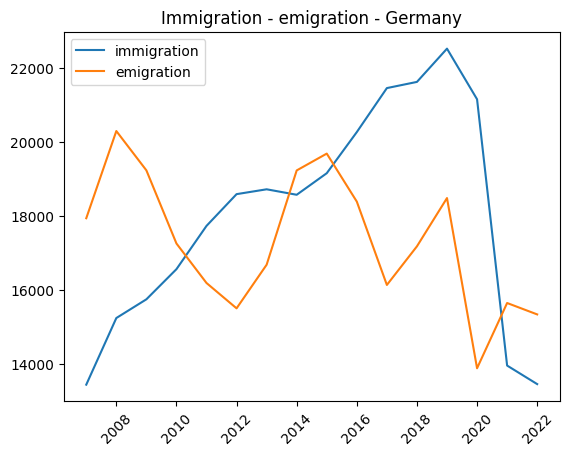

In [3]:
sql = "SELECT Year FROM migration"
result = pd.read_sql(sql,conn)
year = result['Year'].tolist()

sql = "SELECT Immigration FROM migration"
result = pd.read_sql(sql,conn)
immigration = result['Immigration'].tolist()

sql = "SELECT Emigration FROM migration"
result = pd.read_sql(sql,conn)
emigration = result['Emigration'].tolist()


df = pd.DataFrame({'immigration': immigration, 'emigration': emigration}, index=year)
plot = df.plot(title="Immigration - emigration - Germany", rot=45)

<font color='#5891db'>While immigration to Germany is fluctuatingly decreasing, emigration to England will increase until 2020 and then fall sharply.</font>

### select where from table

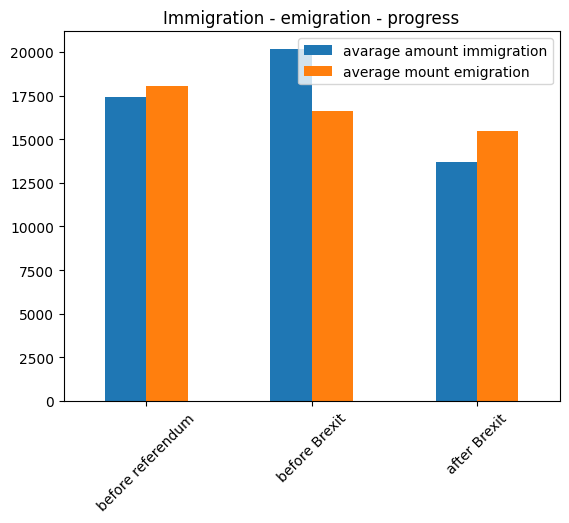

In [4]:
sql = "SELECT AVG(Immigration), AVG(Emigration) FROM migration WHERE Year <= 2016"
result = pd.read_sql(sql,conn)
before_ref_immigration = result['AVG(Immigration)'].loc[0]
before_ref_emigration = result['AVG(Emigration)'].loc[0]

sql = "SELECT AVG(Immigration), AVG(Emigration) FROM migration WHERE Year BETWEEN  2016 AND 2021"
result = pd.read_sql(sql,conn)
before_brex_immigration = result['AVG(Immigration)'].loc[0]
before_brex_emigration = result['AVG(Emigration)'].loc[0]

sql = "SELECT AVG(Immigration), AVG(Emigration) FROM migration WHERE Year > 2020"
result = pd.read_sql(sql,conn)
after_brex_immigration = result['AVG(Immigration)'].loc[0]
after_brex_emigration = result['AVG(Emigration)'].loc[0]

df = pd.DataFrame({'avarage amount immigration' : [before_ref_immigration, before_brex_immigration, after_brex_immigration], 'average mount emigration' : [before_ref_emigration, before_brex_emigration , after_brex_emigration]}, index = ['before referendum', 'before Brexit', 'after Brexit'])
plot = df.plot.bar(title="Immigration - emigration - progress", rot=45)

<font color='#5891db'>Average immigration during the three phases of Brexit decreases, while average emigration peaks after the referendum but before Brexit.</font>

### display missing data

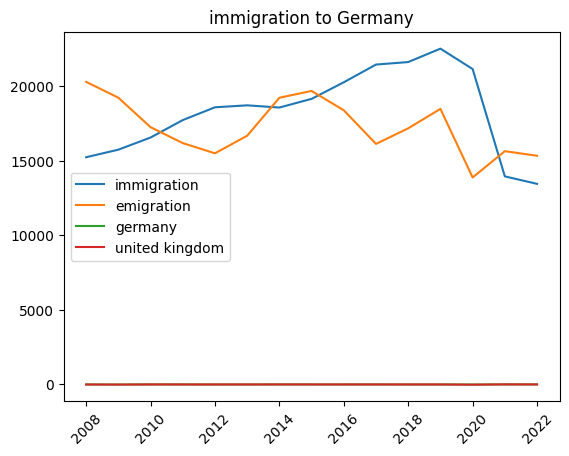

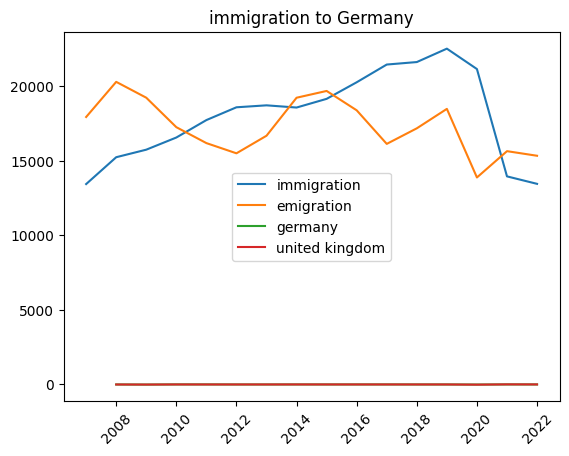

In [5]:
conn = sqlite3.connect('brexit.db')

# LEFT (OUTER) JOIN
sql = "SELECT migration.Year, migration.Immigration, migration.Emigration, `economic-growth`.Germany, `economic-growth`.`United Kingdom` FROM `economic-growth` LEFT JOIN migration ON migration.Year = `economic-growth`.Jahr ORDER BY migration.Year"
result = pd.read_sql(sql,conn)

year = result['Year'].tolist()
immigration = result['Immigration'].tolist()
emigration = result['Emigration'].tolist()

germany = result['Germany'].tolist()
germany = [np.NaN if x=='NaN' else x for x in germany]
united_kingdom = result['United Kingdom'].tolist()
united_kingdom = [np.NaN if x=='NaN' else x for x in united_kingdom]

df = pd.DataFrame({'immigration': immigration, 'emigration': emigration, 'germany': germany, 'united kingdom': united_kingdom}, index=year)
plot = df.plot(title="immigration to Germany", rot=45)


# RIGHT (OUTER) JOIN
sql = "SELECT migration.Year, migration.Immigration, migration.Emigration, `economic-growth`.Germany, `economic-growth`.`United Kingdom` FROM `economic-growth` RIGHT JOIN migration ON migration.Year = `economic-growth`.Jahr ORDER BY migration.Year"
result = pd.read_sql(sql,conn)

year = result['Year'].tolist()
immigration = result['Immigration'].tolist()
emigration = result['Emigration'].tolist()

germany = result['Germany'].tolist()
germany = [np.NaN if x=='NaN' else x for x in germany]
united_kingdom = result['United Kingdom'].tolist()
united_kingdom = [np.NaN if x=='NaN' else x for x in united_kingdom]

df = pd.DataFrame({'immigration': immigration, 'emigration': emigration, 'germany': germany, 'united kingdom': united_kingdom}, index=year)
plot = df.plot(title="immigration to Germany", rot=45)

conn.close()

#  <font color='#bd1c3f'>LINEAR REGRESSION</font> <br>These questions arise

## 1. Immigration - Emigration - Time

1.1 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Immigration nach Deutschland vor dem Referendung?

1.2 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Emigration nach Deutschland vor dem Referendung?

1.3 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Immigration nach Deutschland vor dem Brexit?

1.4 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Emigration nach Deutschland vor dem Brexit?

1.5 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Immigration nach Deutschland nach dem Brexit?

1.6 Gibt es einen zeitlich linearen Zusammenhang bezüglich der Emigration nach Deutschland nach dem Brexit?

## 2. Immigration - Emigration - Economic-Growth

2.1  Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Immigration nach Deutschland vor dem Referendum?

2.2  Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Emigration nach Deutschland vor dem Referendum?

2.3 Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Immigration nach Deutschland vor dem Bexit?

2.4 Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Emigration nach Deutschland vor dem Bexit?

2.5 Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Immigration nach Deutschland nach dem Bexit?

2.6 Gibt es einen linearen Zusammenhang zwischen dem Wirtschaftswachstum und der Emigration nach Deutschland nach dem Bexit?

#  <font color='#bd1c3f'>MULTIPLE REGRESSION</font> <br>These questions arise

## 3. Immigration - Emigration - Economic-Growth

3.1 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Immigration nach Deutschland vor dem Referendum?

3.2 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Emigration nach Deutschland vor dem Referendum?

3.3 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Immigration nach Deutschland vor dem Brexit?

3.4 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Emigration nach Deutschland vor dem Brexit?

3.5 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Immigration nach Deutschland nach dem Brexit?

3.6 Gibt es einen Zusammenhang zwischen dem Wirtschaftswachstum, der Zeit und der Emmigration nach Deutschland nach dem Brexit?

#  <font color='#bd1c3f'>WIE HÄTTEN SICH DIE IMMIGRATION UND EMIGRATION GESTALTET HÄTTE ES DEN BREXIT NICHT GEGEBEN?</font> <br>

4.1 linear Model - Immigration - Zeit

4.2 lineares Model - Emigration - Zeit

4.3 linear Model - Immigration - Economic-Growth

4.4 linear Model - Emigration - Economic-Growth

4.5 multiple Model - Immigration - Time - Economic-Growth

4.6 multiple Model - Emigration - Time - Economic-Growth